# Week 4 Assignment — Convolutional VAE on MNIST

This notebook completes **Week 4: Convolutional VAE on MNIST**.

## What this notebook contains

1. Train a **ConvVAE** on MNIST.
2. Track and plot **BCE** and **KL divergence** separately.
3. Show all four required visualizations:
   - Original vs reconstructed digits
   - Generated samples from random noise
   - t-SNE plot of latent codes
   - Latent interpolation between two digits
4. Run the required **β experiment** with β = 0.0, 0.5, and 2.0.
5. Answer: **What changes as β increases, and why?**

This is the image version of the Week 3 Linear VAE. The main change is that `nn.Linear` layers are replaced by `nn.Conv2d` and `nn.ConvTranspose2d` because images have spatial structure.


## 1. Imports and Setup

Run this cell first. It imports PyTorch, torchvision, matplotlib, NumPy, and t-SNE.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)



## 2. Load MNIST Dataset

MNIST images are grayscale handwritten digits of shape **1 × 28 × 28**.

`transforms.ToTensor()` converts each image into a tensor and scales pixel values to the range `[0, 1]`.


In [4]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.34MB/s]

Batch shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Pixel range: [0.00, 1.00]


## 3. Visualize Some MNIST Samples

Before training a model, always look at the data.


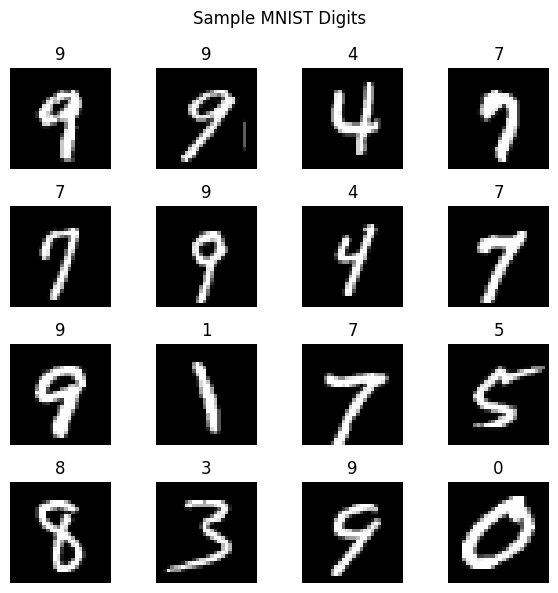

In [5]:
def show_mnist_batch(loader, n=16):
    images, labels = next(iter(loader))
    plt.figure(figsize=(6, 6))
    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i, 0], cmap="gray")
        plt.title(str(labels[i].item()))
        plt.axis("off")
    plt.suptitle("Sample MNIST Digits")
    plt.tight_layout()
    plt.show()

show_mnist_batch(train_loader)


## 4. ConvVAE Model

### Encoder

The encoder compresses an image:

$$1 \times 28 \times 28 \rightarrow 32 \times 14 \times 14 \rightarrow 64 \times 7 \times 7 \rightarrow 128 \times 3 \times 3$$

Then it flattens the result and produces two vectors:

$$\mu$$ and $$\log(\sigma^2)$$

### Reparameterization trick

Instead of sampling directly from the encoder distribution, we use:

$$z = \mu + \sigma \cdot \epsilon$$

where:

$$\epsilon \sim \mathcal{N}(0, I)$$

This allows backpropagation to work through the sampling step.

### Decoder

The decoder takes the latent vector and reconstructs the image.


In [6]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=20, hidden_dims=None):
        super().__init__()

        self.latent_dim = latent_dim

        if hidden_dims is None:
            hidden_dims = [32, 64, 128]

        self.hidden_dims = hidden_dims
        self.last_channel = hidden_dims[-1]
        self.flattened_size = self.last_channel * 3 * 3

        # Encoder: [B, 1, 28, 28] -> [B, 128, 3, 3]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, hidden_dims[0], kernel_size=3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(hidden_dims[0], hidden_dims[1], kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),
            nn.Conv2d(hidden_dims[1], hidden_dims[2], kernel_size=3, stride=2, padding=0), # 7 -> 3
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims[2], hidden_dims[1], kernel_size=4, stride=2, padding=1), # 3 -> 6
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dims[1], hidden_dims[0], kernel_size=4, stride=2, padding=1), # 6 -> 12
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dims[0], 1, kernel_size=4, stride=2, padding=1), # 12 -> 24
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon
        return z

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.last_channel, 3, 3)
        recon = self.decoder(h)
        return recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


## 5. Loss Function

The VAE loss has two parts:

$$\mathcal{L}_{VAE} = \mathcal{L}_{reconstruction} + \beta \cdot D_{KL}$$

For MNIST, we use Binary Cross Entropy because pixel values are between 0 and 1.

The KL divergence term is:

$$D_{KL} = -\frac{1}{2}\sum(1 + \log(\sigma^2) - \mu^2 - \sigma^2)$$

The decoder output is **24 × 24**, so we resize it to **28 × 28** before computing the reconstruction loss.


In [7]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    # Resize decoder output from 24x24 to 28x28
    recon_resized = F.interpolate(recon, size=(28, 28), mode="bilinear", align_corners=False)

    # Reconstruction loss
    bce = F.binary_cross_entropy(recon_resized, x, reduction="sum")

    # KL divergence
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = bce + beta * kld

    return total_loss, bce, kld


## 6. Training and Evaluation Functions

These functions train the model for one epoch and evaluate it on the test set.


In [8]:
def train_epoch(model, loader, optimizer, beta=1.0):
    model.train()

    total_loss = 0
    total_bce = 0
    total_kld = 0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)
        loss, bce, kld = vae_loss(recon, x, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    n = len(loader.dataset)
    return total_loss / n, total_bce / n, total_kld / n


def evaluate(model, loader, beta=1.0):
    model.eval()

    total_loss = 0
    total_bce = 0
    total_kld = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            recon, mu, logvar = model(x)
            loss, bce, kld = vae_loss(recon, x, mu, logvar, beta=beta)

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()

    n = len(loader.dataset)
    return total_loss / n, total_bce / n, total_kld / n


## 7. Train the Main ConvVAE Model

The assignment asks for **30 epochs**.

If you are testing quickly, set `EPOCHS = 3` first. For final submission, change it back to `30`.


In [10]:
LATENT_DIM = 20
LEARNING_RATE = 1e-3
EPOCHS = 30
BETA = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "train_bce": [],
    "train_kld": [],
    "test_loss": [],
    "test_bce": [],
    "test_kld": []
}

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train BCE':>12} {'Train KLD':>12} {'Test Loss':>12} {'Test BCE':>12} {'Test KLD':>12}")
print("-" * 85)

for epoch in range(1, EPOCHS + 1):
    train_l, train_b, train_k = train_epoch(model, train_loader, optimizer, beta=BETA)
    test_l, test_b, test_k = evaluate(model, test_loader, beta=BETA)

    history["train_loss"].append(train_l)
    history["train_bce"].append(train_b)
    history["train_kld"].append(train_k)
    history["test_loss"].append(test_l)
    history["test_bce"].append(test_b)
    history["test_kld"].append(test_k)

    print(f"{epoch:>5} {train_l:>12.2f} {train_b:>12.2f} {train_k:>12.2f} {test_l:>12.2f} {test_b:>12.2f} {test_k:>12.2f}")

print("Training complete.")

Epoch   Train Loss    Train BCE    Train KLD    Test Loss     Test BCE     Test KLD
-------------------------------------------------------------------------------------
    1       170.49       156.19        14.30       117.79        96.56        21.24
    2       112.24        89.47        22.78       108.52        85.21        23.31
    3       107.80        84.60        23.20       105.79        82.40        23.39
    4       106.09        82.83        23.26       105.19        81.46        23.73
    5       105.16        81.87        23.29       104.09        81.67        22.42
    6       104.33        81.08        23.25       103.47        79.84        23.63
    7       103.76        80.60        23.16       103.22        80.94        22.28
    8       103.36        80.23        23.14       102.72        79.21        23.51
    9       102.96        79.85        23.11       102.37        79.83        22.54
   10       102.68        79.58        23.10       102.17        79.26    

## 8. Plot BCE and KL Separately

This is required for Part 1 of the assignment.


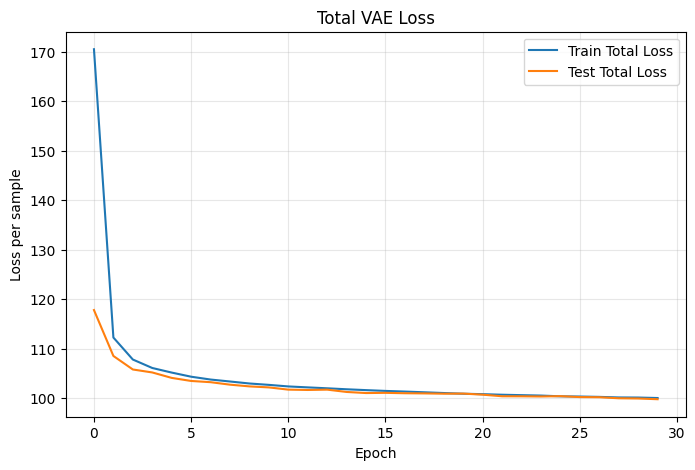

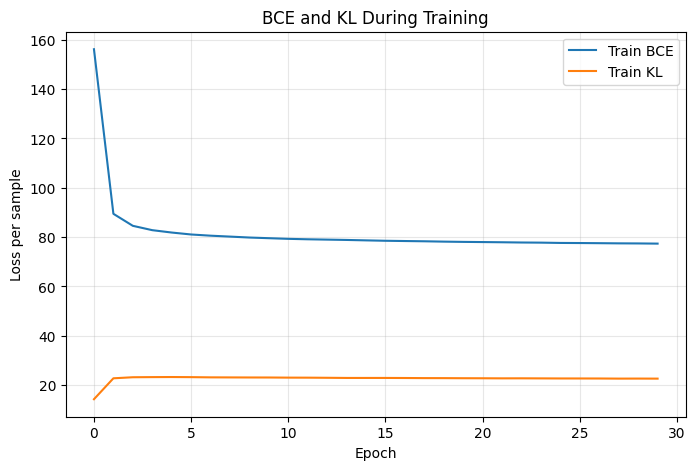

In [11]:
def plot_losses(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Total Loss")
    plt.plot(history["test_loss"], label="Test Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss per sample")
    plt.title("Total VAE Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_bce"], label="Train BCE")
    plt.plot(history["train_kld"], label="Train KL")
    plt.xlabel("Epoch")
    plt.ylabel("Loss per sample")
    plt.title("BCE and KL During Training")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_losses(history)


# Part 2 — Required Visualizations

The assignment asks for four visualizations.


## Visualization 1: Original vs Reconstructed Digits

Top row: original MNIST digits  
Bottom row: reconstructed digits from the VAE


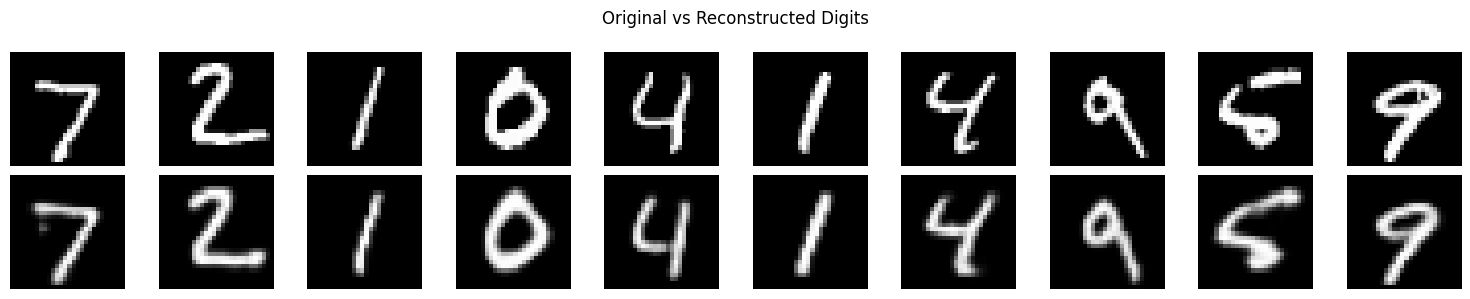

In [12]:
@torch.no_grad()
def show_reconstructions(model, loader, n=10):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    recon, _, _ = model(x)
    recon = F.interpolate(recon, size=(28, 28), mode="bilinear", align_corners=False)

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3))

    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(recon[i, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Reconstructed")

    plt.suptitle("Original vs Reconstructed Digits")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=10)


## Visualization 2: Generated Digits from Random Noise

Here we sample:

$$z \sim \mathcal{N}(0, I)$$

Then we pass `z` through the decoder.


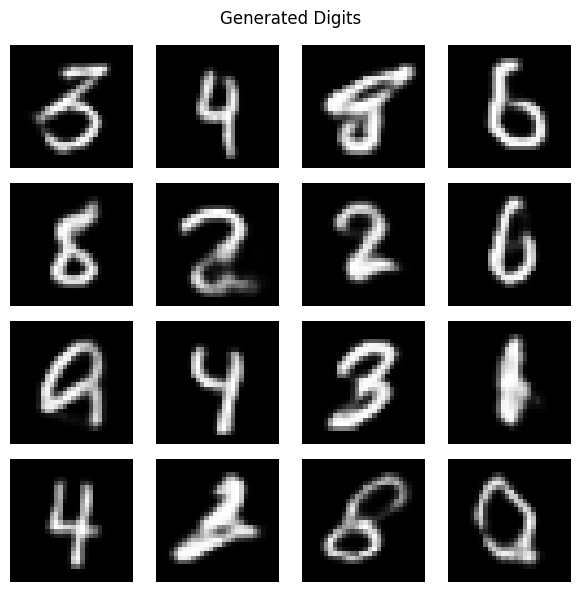

In [13]:
@torch.no_grad()
def generate_digits(model, n=16, latent_dim=20, title="Generated Digits"):
    model.eval()

    z = torch.randn(n, latent_dim).to(device)
    samples = model.decode(z)
    samples = F.interpolate(samples, size=(28, 28), mode="bilinear", align_corners=False)

    grid_size = int(np.sqrt(n))
    plt.figure(figsize=(6, 6))

    for i in range(n):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(samples[i, 0].cpu(), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

generate_digits(model, n=16, latent_dim=LATENT_DIM)


## Visualization 3: t-SNE of Latent Codes

The encoder is trained without labels. But after training, we can color latent codes by digit label to check whether similar digits form clusters.


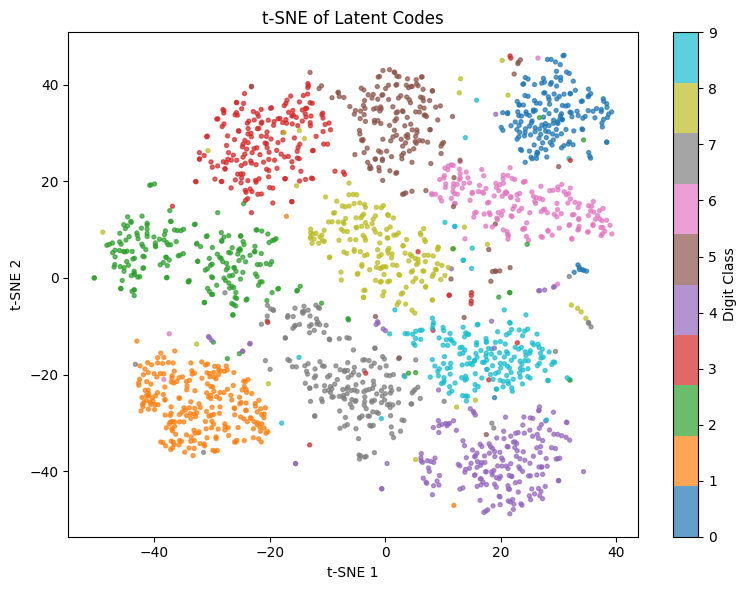

In [14]:
@torch.no_grad()
def plot_latent_tsne(model, loader, n_samples=2000):
    model.eval()

    all_z = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        mu, _ = model.encode(x)

        all_z.append(mu.cpu())
        all_labels.append(y)

        if sum(batch.shape[0] for batch in all_z) >= n_samples:
            break

    z = torch.cat(all_z, dim=0)[:n_samples].numpy()
    labels = torch.cat(all_labels, dim=0)[:n_samples].numpy()

    z_2d = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        init="pca",
        learning_rate="auto"
    ).fit_transform(z)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    plt.colorbar(scatter, label="Digit Class")
    plt.title("t-SNE of Latent Codes")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

plot_latent_tsne(model, test_loader)


## Visualization 4: Latent Space Interpolation

This shows a smooth morph between two digits by interpolating between their latent vectors.


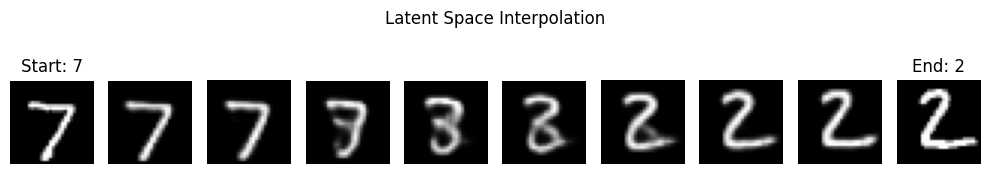

In [15]:
@torch.no_grad()
def interpolate_digits(model, loader, steps=8):
    model.eval()

    x, y = next(iter(loader))

    # Choose two different digit classes if possible
    idx1 = 0
    idx2 = 1
    for j in range(1, len(y)):
        if y[j] != y[idx1]:
            idx2 = j
            break

    img1 = x[idx1:idx1+1].to(device)
    img2 = x[idx2:idx2+1].to(device)

    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

    alphas = torch.linspace(0, 1, steps).to(device)
    recons = []

    for alpha in alphas:
        z = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z)
        recon = F.interpolate(recon, size=(28, 28), mode="bilinear", align_corners=False)
        recons.append(recon)

    fig, axes = plt.subplots(1, steps + 2, figsize=(steps + 2, 2))

    axes[0].imshow(img1[0, 0].cpu(), cmap="gray")
    axes[0].set_title(f"Start: {y[idx1].item()}")
    axes[0].axis("off")

    for i, recon in enumerate(recons):
        axes[i + 1].imshow(recon[0, 0].cpu(), cmap="gray")
        axes[i + 1].axis("off")

    axes[-1].imshow(img2[0, 0].cpu(), cmap="gray")
    axes[-1].set_title(f"End: {y[idx2].item()}")
    axes[-1].axis("off")

    plt.suptitle("Latent Space Interpolation")
    plt.tight_layout()
    plt.show()

interpolate_digits(model, test_loader, steps=8)


# Part 3 — β Experiment

The assignment asks us to train three separate models:

- β = 0.0
- β = 0.5
- β = 2.0

For each value, we generate 16 digits from random noise.


In [16]:
def train_model_for_beta(beta, epochs=30, latent_dim=20, learning_rate=1e-3):
    beta_model = ConvVAE(latent_dim=latent_dim).to(device)
    beta_optimizer = optim.Adam(beta_model.parameters(), lr=learning_rate)

    beta_history = {
        "train_loss": [],
        "train_bce": [],
        "train_kld": []
    }

    print(f"Training model with beta = {beta}")

    for epoch in range(1, epochs + 1):
        train_l, train_b, train_k = train_epoch(beta_model, train_loader, beta_optimizer, beta=beta)

        beta_history["train_loss"].append(train_l)
        beta_history["train_bce"].append(train_b)
        beta_history["train_kld"].append(train_k)

        print(f"Epoch {epoch:02d}/{epochs} | Loss: {train_l:.2f} | BCE: {train_b:.2f} | KL: {train_k:.2f}")

    return beta_model, beta_history


## Run β = 0.0, 0.5, and 2.0

For final submission, keep `BETA_EPOCHS = 30`.

For a quick test, use `BETA_EPOCHS = 3`.


Training model with beta = 0.0
Epoch 01/30 | Loss: 147.34 | BCE: 147.34 | KL: 659.05
Epoch 02/30 | Loss: 77.85 | BCE: 77.85 | KL: 1037.68
Epoch 03/30 | Loss: 73.20 | BCE: 73.20 | KL: 888.84
Epoch 04/30 | Loss: 71.56 | BCE: 71.56 | KL: 770.49
Epoch 05/30 | Loss: 70.58 | BCE: 70.58 | KL: 672.19
Epoch 06/30 | Loss: 69.89 | BCE: 69.89 | KL: 594.78
Epoch 07/30 | Loss: 69.40 | BCE: 69.40 | KL: 536.73
Epoch 08/30 | Loss: 68.98 | BCE: 68.98 | KL: 483.96
Epoch 09/30 | Loss: 68.65 | BCE: 68.65 | KL: 443.43
Epoch 10/30 | Loss: 68.37 | BCE: 68.37 | KL: 414.02
Epoch 11/30 | Loss: 68.11 | BCE: 68.11 | KL: 388.34
Epoch 12/30 | Loss: 67.92 | BCE: 67.92 | KL: 361.22
Epoch 13/30 | Loss: 67.73 | BCE: 67.73 | KL: 342.12
Epoch 14/30 | Loss: 67.57 | BCE: 67.57 | KL: 324.41
Epoch 15/30 | Loss: 67.41 | BCE: 67.41 | KL: 310.41
Epoch 16/30 | Loss: 67.27 | BCE: 67.27 | KL: 297.11
Epoch 17/30 | Loss: 67.15 | BCE: 67.15 | KL: 290.09
Epoch 18/30 | Loss: 67.02 | BCE: 67.02 | KL: 281.43
Epoch 19/30 | Loss: 66.92 | BC

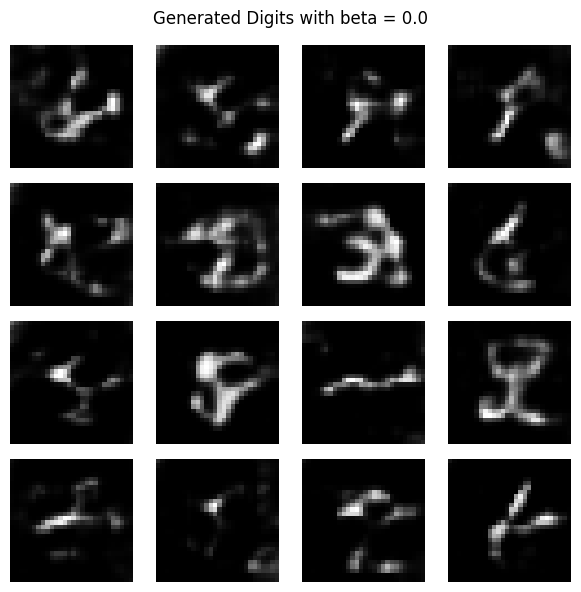

Training model with beta = 0.5
Epoch 01/30 | Loss: 160.39 | BCE: 149.34 | KL: 22.09
Epoch 02/30 | Loss: 99.04 | BCE: 83.13 | KL: 31.81
Epoch 03/30 | Loss: 94.47 | BCE: 78.51 | KL: 31.93
Epoch 04/30 | Loss: 92.76 | BCE: 76.81 | KL: 31.91
Epoch 05/30 | Loss: 91.77 | BCE: 75.86 | KL: 31.82
Epoch 06/30 | Loss: 91.08 | BCE: 75.19 | KL: 31.77
Epoch 07/30 | Loss: 90.56 | BCE: 74.72 | KL: 31.69
Epoch 08/30 | Loss: 90.16 | BCE: 74.35 | KL: 31.62
Epoch 09/30 | Loss: 89.76 | BCE: 73.98 | KL: 31.56
Epoch 10/30 | Loss: 89.52 | BCE: 73.78 | KL: 31.48
Epoch 11/30 | Loss: 89.28 | BCE: 73.57 | KL: 31.42
Epoch 12/30 | Loss: 89.05 | BCE: 73.36 | KL: 31.38
Epoch 13/30 | Loss: 88.85 | BCE: 73.18 | KL: 31.33
Epoch 14/30 | Loss: 88.65 | BCE: 73.03 | KL: 31.24
Epoch 15/30 | Loss: 88.49 | BCE: 72.91 | KL: 31.16
Epoch 16/30 | Loss: 88.33 | BCE: 72.77 | KL: 31.13
Epoch 17/30 | Loss: 88.24 | BCE: 72.70 | KL: 31.08
Epoch 18/30 | Loss: 88.09 | BCE: 72.57 | KL: 31.03
Epoch 19/30 | Loss: 87.96 | BCE: 72.46 | KL: 30.9

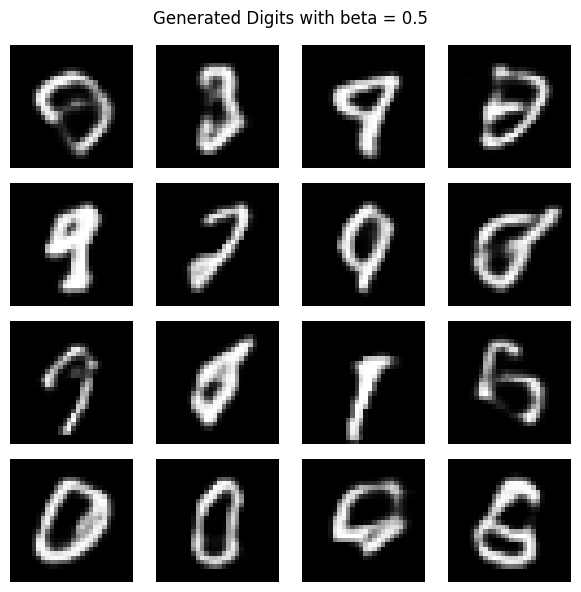

Training model with beta = 2.0
Epoch 01/30 | Loss: 174.34 | BCE: 155.83 | KL: 9.25
Epoch 02/30 | Loss: 129.99 | BCE: 100.84 | KL: 14.58
Epoch 03/30 | Loss: 126.27 | BCE: 95.97 | KL: 15.15
Epoch 04/30 | Loss: 124.62 | BCE: 93.90 | KL: 15.36
Epoch 05/30 | Loss: 123.59 | BCE: 92.74 | KL: 15.42
Epoch 06/30 | Loss: 122.82 | BCE: 91.81 | KL: 15.50
Epoch 07/30 | Loss: 122.29 | BCE: 91.24 | KL: 15.52
Epoch 08/30 | Loss: 121.79 | BCE: 90.75 | KL: 15.52
Epoch 09/30 | Loss: 121.45 | BCE: 90.38 | KL: 15.54
Epoch 10/30 | Loss: 121.11 | BCE: 90.04 | KL: 15.53
Epoch 11/30 | Loss: 120.87 | BCE: 89.73 | KL: 15.57
Epoch 12/30 | Loss: 120.59 | BCE: 89.52 | KL: 15.54
Epoch 13/30 | Loss: 120.36 | BCE: 89.23 | KL: 15.57
Epoch 14/30 | Loss: 120.10 | BCE: 88.99 | KL: 15.55
Epoch 15/30 | Loss: 119.99 | BCE: 88.88 | KL: 15.56
Epoch 16/30 | Loss: 119.73 | BCE: 88.67 | KL: 15.53
Epoch 17/30 | Loss: 119.60 | BCE: 88.52 | KL: 15.54
Epoch 18/30 | Loss: 119.47 | BCE: 88.41 | KL: 15.53
Epoch 19/30 | Loss: 119.27 | BCE

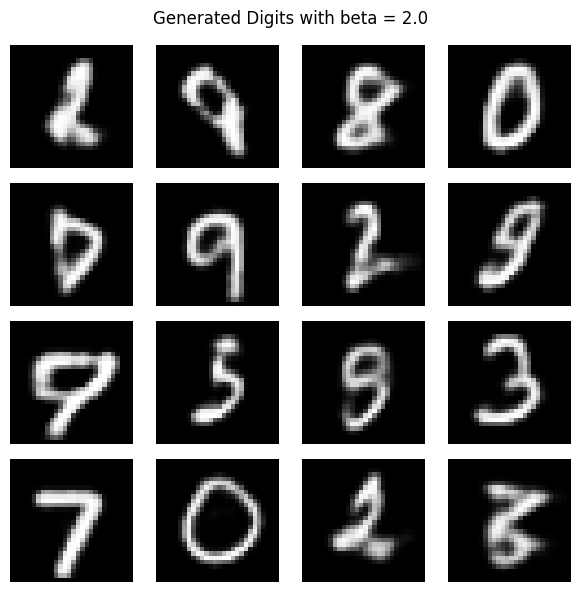

In [17]:
BETA_EPOCHS = 30
beta_values = [0.0, 0.5, 2.0]

beta_models = {}
beta_histories = {}

for beta in beta_values:
    beta_model, beta_history = train_model_for_beta(
        beta=beta,
        epochs=BETA_EPOCHS,
        latent_dim=LATENT_DIM,
        learning_rate=LEARNING_RATE
    )

    beta_models[beta] = beta_model
    beta_histories[beta] = beta_history

    generate_digits(
        beta_model,
        n=16,
        latent_dim=LATENT_DIM,
        title=f"Generated Digits with beta = {beta}"
    )


## β Experiment Answer
For β = 0.0, the generated samples are mostly noisy and unrecognizable. The reconstruction loss is low because the model focuses entirely on reconstructing the training images and completely ignores the KL divergence. As a result, the latent space becomes irregular and discontinuous. When we sample random latent vectors from the standard normal distribution, these points often fall in regions the decoder never learned during training, so the generated digits look like random blobs instead of valid handwritten numbers.

For β = 0.5, the generated samples become much clearer and resemble actual handwritten digits. Although the reconstructions are slightly blurrier than with β = 0.0, the latent space is now much more organized because the KL divergence regularizes the encoder to produce latent vectors that follow a standard normal distribution. This makes random sampling meaningful, allowing the decoder to generate realistic digits from unseen latent vectors.

As β increases, the model places more emphasis on latent space regularization and less on perfect reconstruction. This creates a smoother and more continuous latent space, improving the quality and diversity of generated samples up to a point. However, if β becomes too large (for example, β = 2.0), the KL term dominates the objective, forcing the latent vectors too close to the standard normal distribution. The decoder then receives very similar latent codes for different images, leading to blurrier reconstructions and, in extreme cases, posterior collapse where every generated image looks almost the same.

In summary: Increasing β trades reconstruction quality for a better-structured latent space. A small β (0.0) gives sharp reconstructions but poor generation, while a moderate β (around 0.5) provides the best balance between reconstruction accuracy and the ability to generate realistic new digits. A very high β over-regularizes the model, resulting in blurry or nearly identical outputs.


# Bonus — KL Annealing

KL annealing starts with β near 0 and slowly increases it.

This helps because early training focuses on learning reconstruction first. After that, the KL term gradually organizes the latent space.


Epoch 01/30 | beta: 0.10 | Loss: 147.60 | BCE: 142.98 | KL: 46.19
Epoch 02/30 | beta: 0.20 | Loss: 88.77 | BCE: 79.69 | KL: 45.43
Epoch 03/30 | beta: 0.30 | Loss: 88.59 | BCE: 76.44 | KL: 40.53
Epoch 04/30 | beta: 0.40 | Loss: 90.72 | BCE: 75.96 | KL: 36.88
Epoch 05/30 | beta: 0.50 | Loss: 93.13 | BCE: 76.19 | KL: 33.89
Epoch 06/30 | beta: 0.60 | Loss: 95.57 | BCE: 76.73 | KL: 31.41
Epoch 07/30 | beta: 0.70 | Loss: 97.95 | BCE: 77.36 | KL: 29.40
Epoch 08/30 | beta: 0.80 | Loss: 100.38 | BCE: 78.20 | KL: 27.73
Epoch 09/30 | beta: 0.90 | Loss: 102.54 | BCE: 79.00 | KL: 26.16
Epoch 10/30 | beta: 1.00 | Loss: 104.69 | BCE: 79.85 | KL: 24.84
Epoch 11/30 | beta: 1.00 | Loss: 104.21 | BCE: 79.67 | KL: 24.54
Epoch 12/30 | beta: 1.00 | Loss: 103.82 | BCE: 79.50 | KL: 24.32
Epoch 13/30 | beta: 1.00 | Loss: 103.48 | BCE: 79.34 | KL: 24.13
Epoch 14/30 | beta: 1.00 | Loss: 103.12 | BCE: 79.18 | KL: 23.94
Epoch 15/30 | beta: 1.00 | Loss: 102.78 | BCE: 79.00 | KL: 23.77
Epoch 16/30 | beta: 1.00 | Los

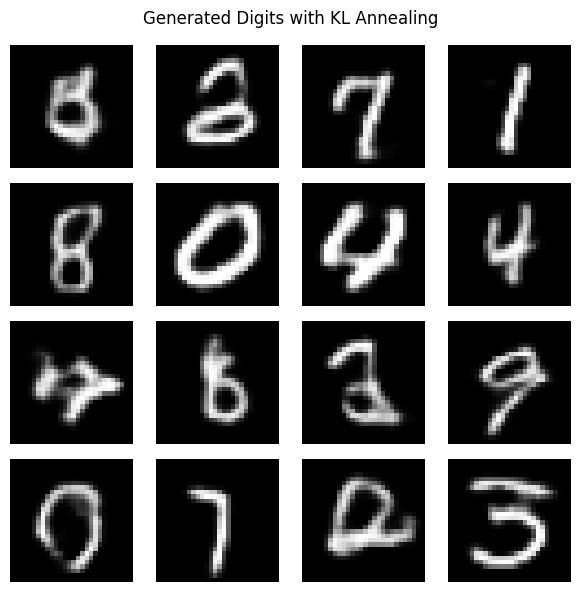

In [19]:
def train_with_kl_annealing(model, loader, optimizer, epochs=30, anneal_epochs=10):
    anneal_history = {
        "train_loss": [],
        "train_bce": [],
        "train_kld": [],
        "beta": []
    }

    for epoch in range(1, epochs + 1):
        beta = min(1.0, epoch / anneal_epochs)

        train_l, train_b, train_k = train_epoch(model, loader, optimizer, beta=beta)

        anneal_history["train_loss"].append(train_l)
        anneal_history["train_bce"].append(train_b)
        anneal_history["train_kld"].append(train_k)
        anneal_history["beta"].append(beta)

        print(f"Epoch {epoch:02d}/{epochs} | beta: {beta:.2f} | Loss: {train_l:.2f} | BCE: {train_b:.2f} | KL: {train_k:.2f}")

    return anneal_history


# Uncomment this section if you want to complete the optional bonus.
annealed_model = ConvVAE(latent_dim=LATENT_DIM).to(device)
annealed_optimizer = optim.Adam(annealed_model.parameters(), lr=LEARNING_RATE)
annealed_history = train_with_kl_annealing(
    annealed_model,
    train_loader,
    annealed_optimizer,
    epochs=30,
    anneal_epochs=10
)
generate_digits(annealed_model, n=16, latent_dim=LATENT_DIM, title="Generated Digits with KL Annealing")


# Final Checklist

Before submitting, make sure your notebook shows:

- Training output for the main ConvVAE model.
- BCE and KL loss plots.
- 10 original vs reconstructed digits.
- 16 generated digits sampled from random noise.
- t-SNE latent space plot.
- 8-step interpolation between two digits.
- β experiment outputs for β = 0.0, 0.5, and 2.0.
- Short written answer explaining the β experiment.
